In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

import os, sys, glob, re, pickle
import numpy as np, pandas as pd
sys.path.append('../src')
from config import IMAGE_SIZE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

In [2]:
df = pd.read_csv("../data/processed/labels.csv", parse_dates=['timestamp'])
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df['month'] = pd.to_datetime(df['timestamp']).dt.month

styled = df.head(8).style.set_table_styles([
    {'selector':'th','props':[('font-family','Times New Roman'),('background-color','#1f77b4'),('color','white')]},
    {'selector':'td','props':[('font-family','Times New Roman')]}
])
display(styled)

,timestamp,temperature,humidity,precipitation,cloud_cover,condition,hour,month
0,2026-05-27 00:00:00,29.700000,62,0.000000,24,Clear,0,5
1,2026-05-27 01:00:00,29.200000,64,0.000000,27,Clear,1,5
2,2026-05-27 02:00:00,28.300000,70,0.000000,9,Clear,2,5
3,2026-05-27 03:00:00,27.300000,76,0.000000,2,Clear,3,5
4,2026-05-27 04:00:00,26.400000,78,0.000000,13,Clear,4,5
5,2026-05-27 05:00:00,25.800000,84,0.000000,5,Clear,5,5
6,2026-05-27 06:00:00,25.900000,82,0.000000,5,Clear,6,5
7,2026-05-27 07:00:00,27.200000,74,0.000000,2,Clear,7,5


In [3]:
X = df[['temperature','humidity','cloud_cover','hour','month']].fillna(0)
y = df['condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

report = classification_report(y_test, clf.predict(X_test), output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df.style.set_table_styles([
    {'selector':'th','props':[('font-family','Times New Roman'),('background-color','#9467bd'),('color','white')]},
    {'selector':'td','props':[('font-family','Times New Roman')]}
]).background_gradient(cmap='Blues', subset=['precision','recall','f1-score']).format("{:.3f}"))

os.makedirs("../models", exist_ok=True)
pickle.dump(clf, open("../models/weather_classifier.pkl","wb"))

Accuracy: 0.8567


,precision,recall,f1-score,support
Clear,0.969,1.000,0.984,127.000
Cloudy,0.862,0.952,0.905,105.000
Heavy Rain,0.462,0.333,0.387,18.000
Light Rain,0.545,0.419,0.474,43.000
accuracy,0.857,0.857,0.857,0.857
macro avg,0.710,0.676,0.688,293.000
weighted avg,0.838,0.857,0.844,293.000


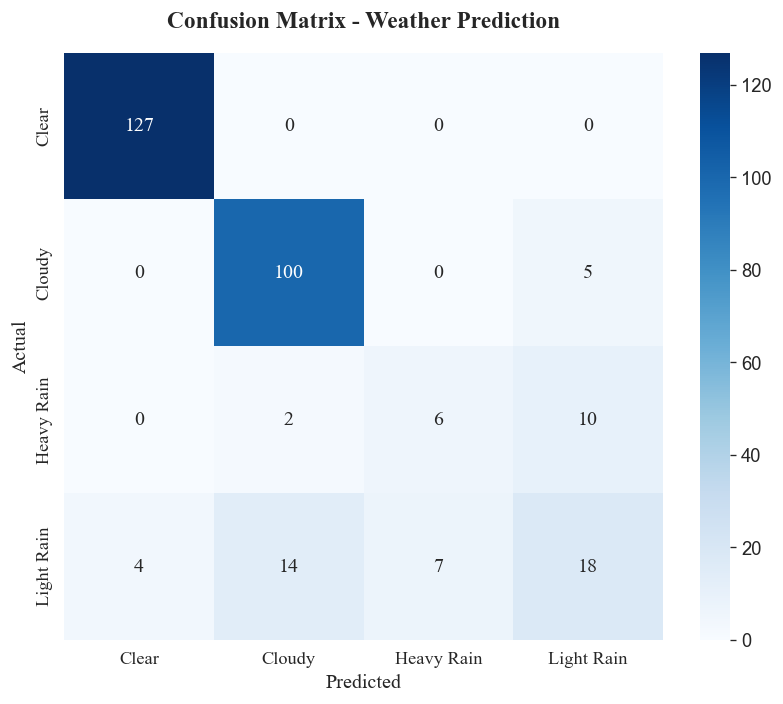

In [4]:
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clf.classes_)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax, annot_kws={"fontname":"Times New Roman", "fontsize":12})
ax.set_title("Confusion Matrix - Weather Prediction", fontname='Times New Roman', fontweight='bold', pad=15)
ax.set_xlabel("Predicted", fontname='Times New Roman')
ax.set_ylabel("Actual", fontname='Times New Roman')
for label in ax.get_xticklabels():
    label.set_fontname('Times New Roman')
for label in ax.get_yticklabels():
    label.set_fontname('Times New Roman')
plt.tight_layout()
plt.show()

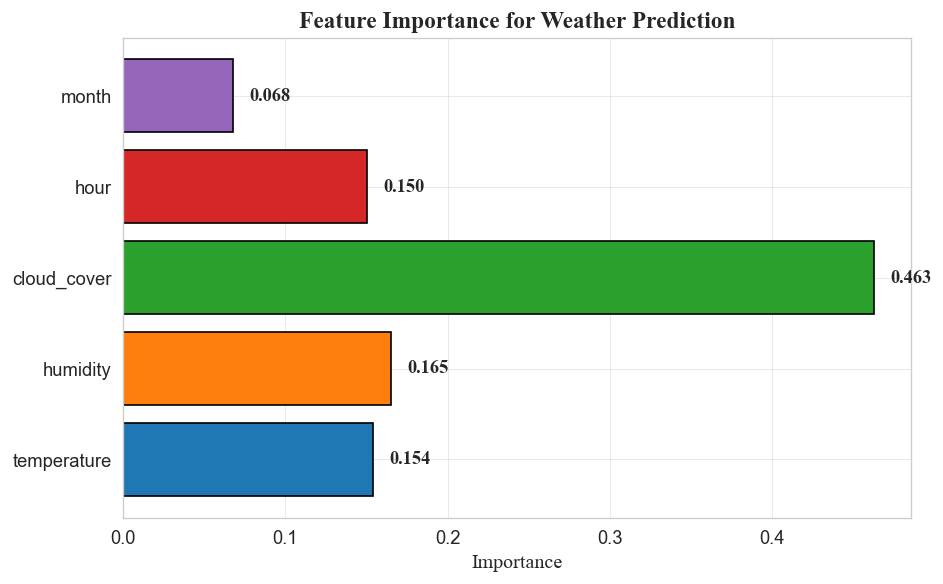

,Feature,Importance
2,cloud_cover,0.4627
1,humidity,0.1652
0,temperature,0.1542
3,hour,0.1503
4,month,0.0675


In [5]:
importances = clf.feature_importances_
features = X.columns
fig, ax = plt.subplots(figsize=(8,5))
colors_imp = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
ax.barh(features, importances, color=colors_imp, edgecolor='black')
ax.set_title("Feature Importance for Weather Prediction", fontname='Times New Roman', fontweight='bold')
ax.set_xlabel("Importance", fontname='Times New Roman')
for i, v in enumerate(importances):
    ax.text(v+0.01, i, f"{v:.3f}", va='center', fontname='Times New Roman', fontweight='bold')
plt.tight_layout()
plt.show()

imp_df = pd.DataFrame({'Feature':features, 'Importance':importances}).sort_values('Importance', ascending=False)
display(imp_df.style.set_table_styles([
    {'selector':'th','props':[('font-family','Times New Roman'),('background-color','#2ca02c'),('color','white')]},
    {'selector':'td','props':[('font-family','Times New Roman')]}
]).background_gradient(cmap='Greens', subset=['Importance']).format({'Importance':"{:.4f}"}))

Found 1 images


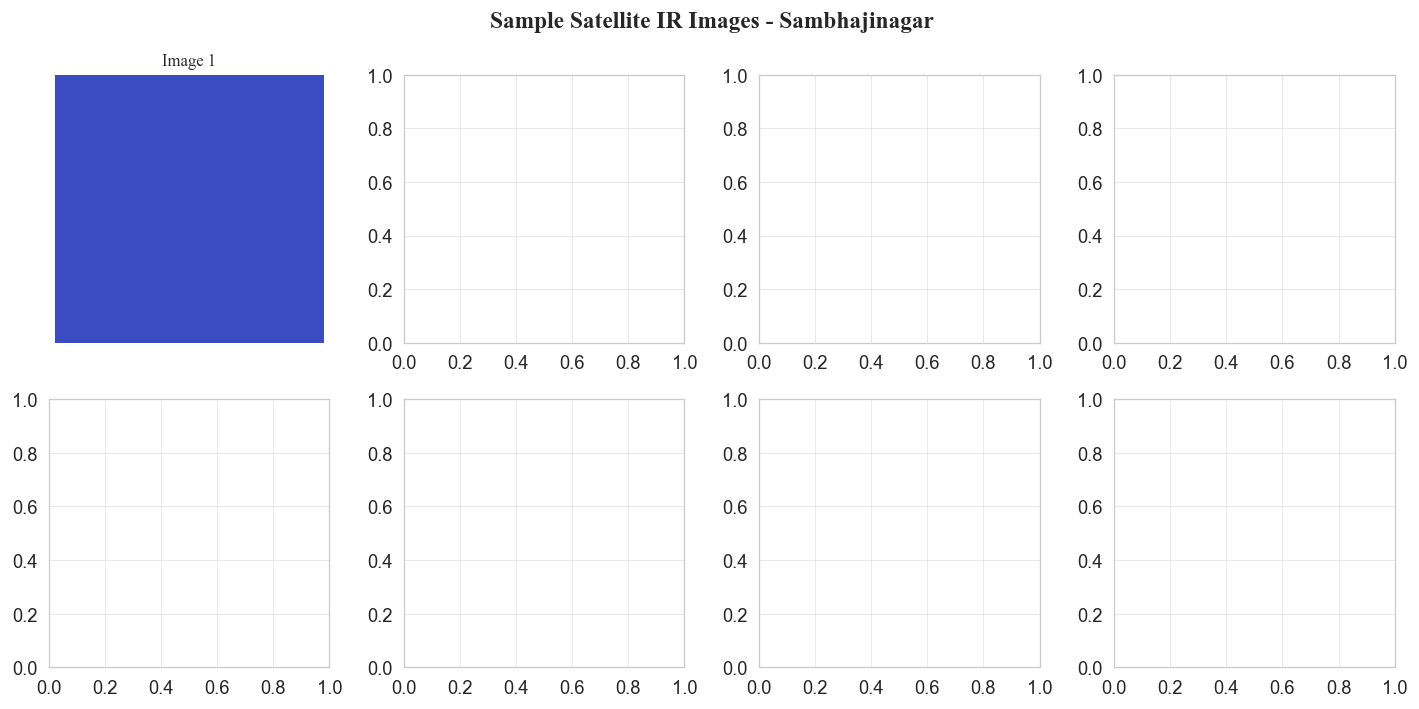

In [6]:
img_files = glob.glob("../data/processed/images/*.npy")
if len(img_files)==0:
    from PIL import Image
    raw_files = glob.glob("../data/raw/*.png")
    os.makedirs("../data/processed/images", exist_ok=True)
    for f in raw_files[:12]:
        try:
            img = Image.open(f).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
            arr = np.array(img)/255.0
            np.save(f"../data/processed/images/{os.path.basename(f).replace('.png','.npy')}", arr.astype(np.float32))
        except: pass
    img_files = glob.glob("../data/processed/images/*.npy")

print(f"Found {len(img_files)} images")
if len(img_files)>0:
    fig, axes = plt.subplots(2, 4, figsize=(12,6))
    axes = axes.flatten()
    for i in range(min(8, len(img_files))):
        arr = np.load(img_files[i])
        axes[i].imshow(arr, cmap='coolwarm', vmin=0, vmax=1)
        axes[i].set_title(f"Image {i+1}", fontname='Times New Roman', fontsize=10)
        axes[i].axis('off')
    plt.suptitle("Sample Satellite IR Images - Sambhajinagar", fontname='Times New Roman', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()